In [ ]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore') # Keeps the notebook clean from pandas fragmentation warnings

# --- CONFIGURATION ---
SYMBOL = 'BTC/USDT'
TIMEFRAME = '4h'
LOOKBACK_DAYS = 730

# 1. Your original OHLCV fetcher
def fetch_data():
    exchange = ccxt.binance({'enableRateLimit': True, 'options': {'defaultType': 'future'}})
    now = exchange.milliseconds()
    since = now - (LOOKBACK_DAYS * 24 * 60 * 60 * 1000)
    all_ohlcv = []
    
    print(f"Fetching OHLCV for {SYMBOL}...")
    while since < now:
        try:
            ohlcv = exchange.fetch_ohlcv(SYMBOL, TIMEFRAME, since, limit=1000)
            if not ohlcv: break
            all_ohlcv.extend(ohlcv)
            since = ohlcv[-1][0] + 1
            if len(ohlcv) < 1000: break
        except Exception as e:
            break

    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('datetime', inplace=True)
    return df[~df.index.duplicated(keep='first')]

# 2. The Funding Rate fetcher
def fetch_funding_data():
    exchange = ccxt.binance({'enableRateLimit': True, 'options': {'defaultType': 'future'}})
    now = exchange.milliseconds()
    since = now - (LOOKBACK_DAYS * 24 * 60 * 60 * 1000)
    all_funding = []
    
    print(f"Fetching Funding Rates for {SYMBOL}...")
    while since < now:
        try:
            funding = exchange.fetch_funding_rate_history(SYMBOL, since=since, limit=1000)
            if not funding: break
            all_funding.extend(funding)
            since = funding[-1]['timestamp'] + 1
            if len(funding) < 1000: break
        except Exception as e:
            break

    df_funding = pd.DataFrame(all_funding)
    if not df_funding.empty:
        df_funding['datetime'] = pd.to_datetime(df_funding['timestamp'], unit='ms')
        df_funding.set_index('datetime', inplace=True)
        df_funding = df_funding[~df_funding.index.duplicated(keep='first')]
        df_funding = df_funding[['fundingRate']]
        df_funding['fundingRate'] = pd.to_numeric(df_funding['fundingRate'])
    return df_funding

# Execute fetches
df = fetch_data()
df_fund = fetch_funding_data()
print("✅ Cell 1 Complete: Data Downloaded.")

Fetching OHLCV for BTC/USDT...
Fetching Funding Rates for BTC/USDT...
✅ Cell 1 Complete: Data Downloaded.


In [21]:
# 1. Merge and forward-fill to prevent look-ahead bias
btc_data = df.join(df_fund, how='left').ffill().dropna()

# 2. Calculate the 20-period SMA for momentum confirmation
btc_data.ta.sma(length=20, append=True)

# 3. Calculate the 42-period (7-day) Funding Rate Z-Score
window = 42
btc_data['fund_mean'] = btc_data['fundingRate'].rolling(window=window).mean()
btc_data['fund_std'] = btc_data['fundingRate'].rolling(window=window).std()
btc_data['fund_zscore'] = (btc_data['fundingRate'] - btc_data['fund_mean']) / btc_data['fund_std']

# Clean up any initial NaNs caused by the rolling window
btc_data.dropna(inplace=True)

print("✅ Cell 2 Complete: Features Engineered.")
btc_data[['close', 'fundingRate', 'SMA_20', 'fund_zscore']].tail() # Inspect the dataframe

✅ Cell 2 Complete: Features Engineered.


,close,fundingRate,SMA_20,fund_zscore
datetime,,,,
2026-03-13 08:00:00,72189.9,-0.000074,70362.075,-0.673230
2026-03-13 12:00:00,71800.0,-0.000074,70433.340,-0.636475
2026-03-13 16:00:00,71148.0,-0.000006,70462.235,0.614109
2026-03-13 20:00:00,70895.5,-0.000006,70442.165,0.657953
2026-03-14 00:00:00,70655.9,-0.000006,70474.700,0.705696


In [22]:
# --- V4.1 ALPHA: ASYMMETRICAL DONCHIAN (FIXED EXECUTION ORDER) ---

# 1. Define Windows & Friction
SLOW_N = 55   
FAST_N = 10   
MACRO_N = 200 
TAKER_FEE = 0.0005 

# 2. Calculate Indicators
btc_data['slow_upper'] = btc_data['high'].rolling(window=SLOW_N).max().shift(1)
btc_data['slow_lower'] = btc_data['low'].rolling(window=SLOW_N).min().shift(1)

btc_data['fast_upper'] = btc_data['high'].rolling(window=FAST_N).max().shift(1)
btc_data['fast_lower'] = btc_data['low'].rolling(window=FAST_N).min().shift(1)

btc_data.ta.sma(length=MACRO_N, append=True)

# 3. The State Machine (EVALUATING EXITS BEFORE ENTRIES)
btc_data['position'] = np.nan

# --- EXITS FIRST (Clear the board) ---
exit_long = (btc_data['low'] < btc_data['fast_lower'])
btc_data.loc[exit_long, 'position'] = 0

exit_short = (btc_data['high'] > btc_data['fast_upper'])
btc_data.loc[exit_short, 'position'] = 0

# --- ENTRIES SECOND (New entries take absolute priority) ---
long_entry = (btc_data['high'] > btc_data['slow_upper']) & (btc_data['close'] > btc_data['SMA_200'])
btc_data.loc[long_entry, 'position'] = 1

short_entry = (btc_data['low'] < btc_data['slow_lower']) & (btc_data['close'] < btc_data['SMA_200'])
btc_data.loc[short_entry, 'position'] = -1

# 4. Forward Fill & Cleanup
btc_data['position'] = btc_data['position'].ffill().fillna(0)
clean_data = btc_data.dropna().copy()

# 5. Market Friction & Returns
clean_data['market_return'] = clean_data['close'].pct_change().shift(-1)
clean_data['strategy_return_gross'] = clean_data['position'].shift(1) * clean_data['market_return']

clean_data['position_change'] = clean_data['position'].diff().abs().fillna(0)
clean_data['fee_penalty'] = clean_data['position_change'] * TAKER_FEE

clean_data['strategy_return_net'] = clean_data['strategy_return_gross'] - clean_data['fee_penalty']
clean_data['cum_market'] = (1 + clean_data['market_return']).cumprod()
clean_data['cum_strategy'] = (1 + clean_data['strategy_return_net']).cumprod()

diagnostic_cum_gross = (1 + clean_data['strategy_return_gross']).cumprod()
gross_total_return = (diagnostic_cum_gross.iloc[-2] - 1) * 100

print("✅ Cell 3 (V4.1) Complete: Execution Order Fixed.")
print(f"Theoretical Gross Return (No Fees): {gross_total_return:.2f}%")
print("Total Trades Executed:\n", clean_data['position_change'].value_counts())

btc_data = clean_data

✅ Cell 3 (V4.1) Complete: Execution Order Fixed.
Theoretical Gross Return (No Fees): 27.87%
Total Trades Executed:
 position_change
0.0    3809
1.0     186
Name: count, dtype: int64


--- V1 Baseline Performance ---
Market Return (Buy & Hold): 7.02%
Strategy Net Return:        16.51%
Sharpe Ratio:               0.43
Max Drawdown:               -25.74%



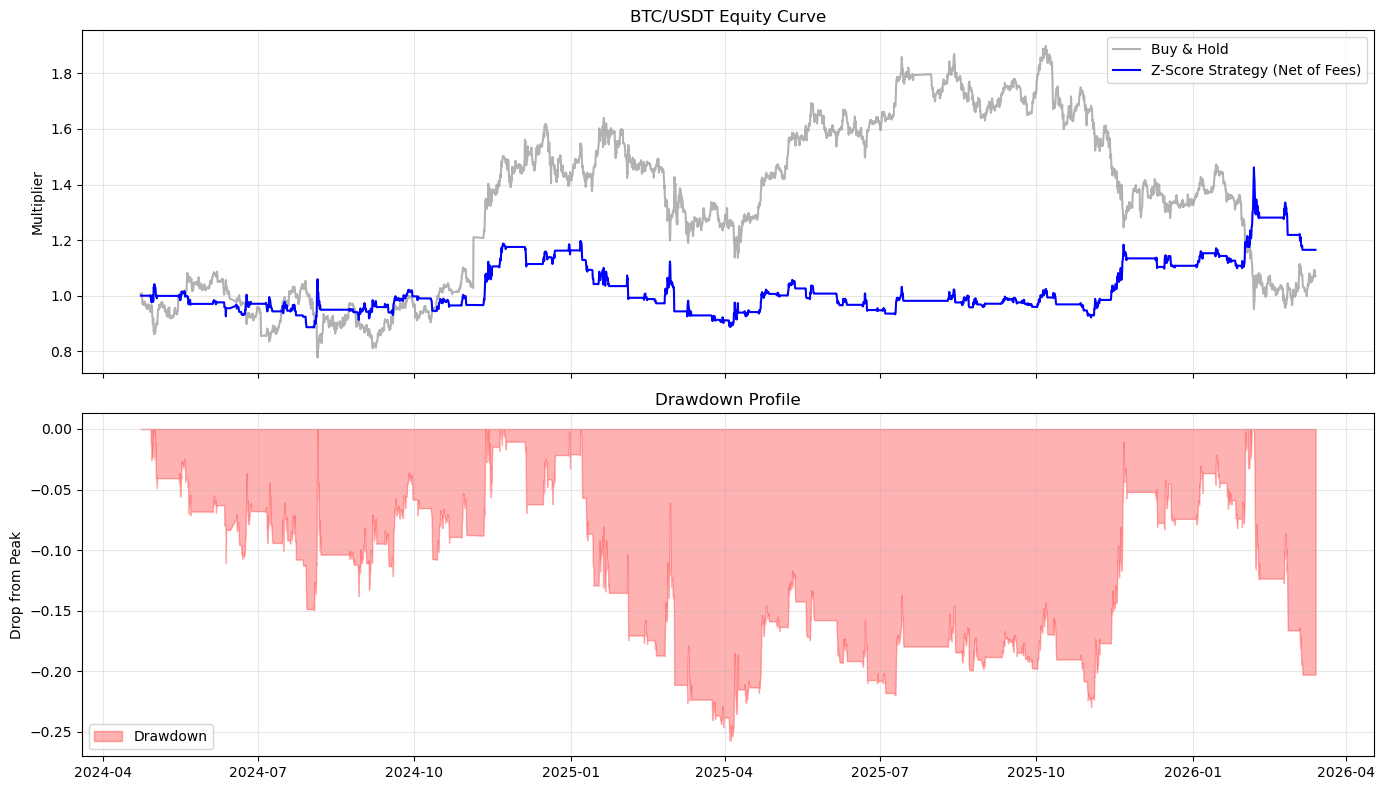

In [23]:
# 1. Metrics Calculation
ANNUAL_FACTOR = 2190 # 6 candles/day * 365 days
mean_ret = btc_data['strategy_return_net'].mean()
std_ret = btc_data['strategy_return_net'].std()

sharpe_ratio = (mean_ret / std_ret) * np.sqrt(ANNUAL_FACTOR) if std_ret > 0 else 0.0

running_max = btc_data['cum_strategy'].cummax()
drawdown = (btc_data['cum_strategy'] - running_max) / running_max
max_drawdown = drawdown.min()

total_return = (btc_data['cum_strategy'].iloc[-2] - 1) * 100
market_return = (btc_data['cum_market'].iloc[-2] - 1) * 100

print(f"--- V1 Baseline Performance ---")
print(f"Market Return (Buy & Hold): {market_return:.2f}%")
print(f"Strategy Net Return:        {total_return:.2f}%")
print(f"Sharpe Ratio:               {sharpe_ratio:.2f}")
print(f"Max Drawdown:               {max_drawdown * 100:.2f}%\n")

# 2. Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(btc_data.index, btc_data['cum_market'], color='gray', label='Buy & Hold', alpha=0.6)
axes[0].plot(btc_data.index, btc_data['cum_strategy'], color='blue', label='Z-Score Strategy (Net of Fees)')
axes[0].set_title(f'{SYMBOL} Equity Curve')
axes[0].set_ylabel('Multiplier')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(btc_data.index, drawdown, 0, color='red', alpha=0.3, label='Drawdown')
axes[1].set_title('Drawdown Profile')
axes[1].set_ylabel('Drop from Peak')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

diagnostic_cum_gross = (1 + btc_data['strategy_return_gross']).cumprod()
gross_total_return = (diagnostic_cum_gross.iloc[-2] - 1) * 100

--- Asset Distribution Metrics ---
BTC 4h Return Skewness: 1.0508


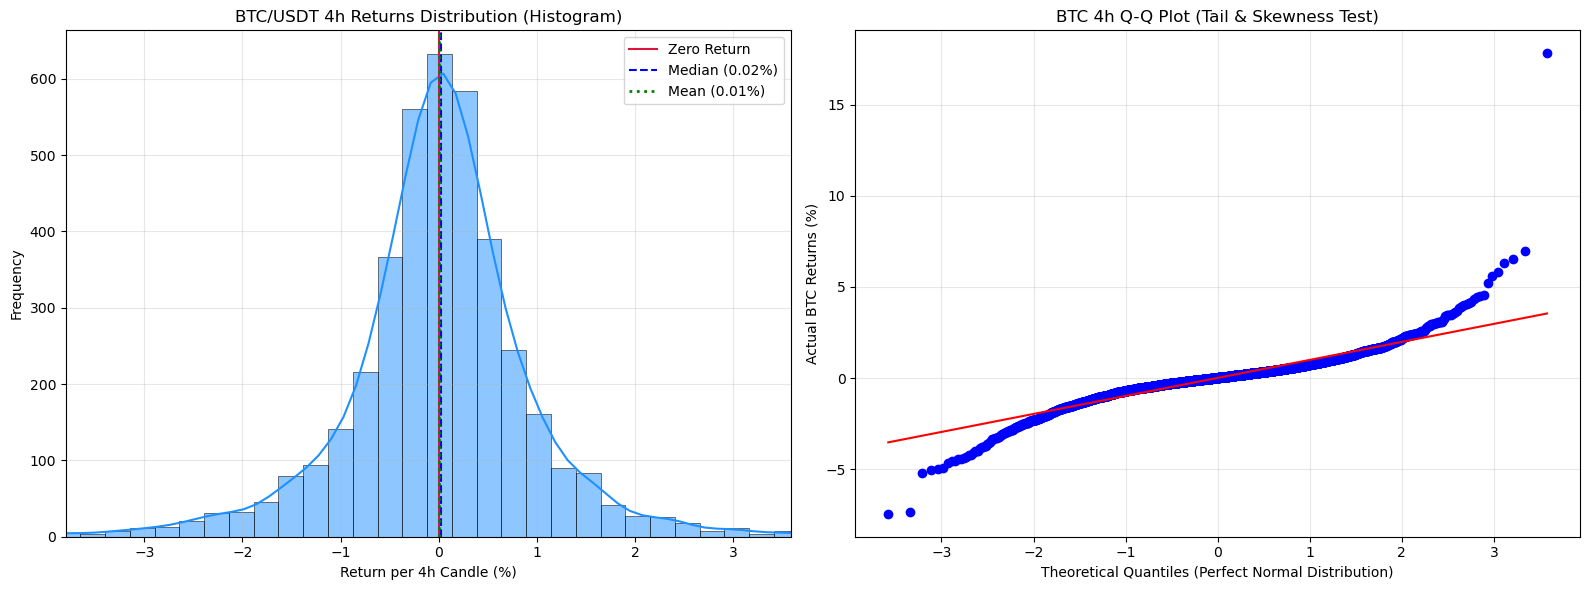

In [58]:
# Drop NaNs to ensure a clean statistical calculation
clean_returns = btc_data['market_return'].dropna()

# 1. Calculate metrics
btc_skew = clean_returns.skew()
mean_val = clean_returns.mean() * 100
median_val = clean_returns.median() * 100

print(f"--- Asset Distribution Metrics ---")
print(f"BTC 4h Return Skewness: {btc_skew:.4f}")

# 2. Create subplots for side-by-side charts (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Histogram and KDE (on the left: axes[0]) ---
sns.histplot(clean_returns * 100, bins=100, color='dodgerblue', kde=True, 
             edgecolor='black', alpha=0.5, ax=axes[0])

axes[0].axvline(0, color='crimson', linestyle='solid', linewidth=1.5, label='Zero Return')
axes[0].axvline(median_val, color='blue', linestyle='dashed', linewidth=1.5, label=f'Median ({median_val:.2f}%)')
axes[0].axvline(mean_val, color='green', linestyle='dotted', linewidth=2, label=f'Mean ({mean_val:.2f}%)')

# Optional: Trim extreme outliers to prevent the chart from squashing
lower_bound = np.percentile(clean_returns * 100, 0.5)
upper_bound = np.percentile(clean_returns * 100, 99.5)
axes[0].set_xlim(lower_bound, upper_bound)

axes[0].set_title(f'{SYMBOL} 4h Returns Distribution (Histogram)')
axes[0].set_xlabel('Return per 4h Candle (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- PLOT 2: Q-Q Plot (on the right: axes[1]) ---
stats.probplot(clean_returns * 100, dist="norm", plot=axes[1])
axes[1].set_title('BTC 4h Q-Q Plot (Tail & Skewness Test)')
axes[1].set_xlabel('Theoretical Quantiles (Perfect Normal Distribution)')
axes[1].set_ylabel('Actual BTC Returns (%)')
axes[1].grid(True, alpha=0.3)

# Display both plots perfectly spaced
plt.tight_layout()
plt.show()